# Data Simulation with `msprime`

This notebook introduces the `msprime` simulator, a high‑performance library for generating ancestry and mutation data under the coalescent. It supports separate ancestry and mutation simulation via the succinct tree sequence data structure. 

`msprime` is widely used in population genetics because it can simulate whole chromosomes efficiently and stores results compactly using `tskit`.

## Learning goals

After working through this notebook we would be able to:

- simulate ancestry and mutations for a constant-size population with `msprime`, and explain why the two steps are separate;
- read a tree sequence: what the trees, branches, and mutations represent;
- extract a genotype (SNP) matrix and the site-frequency spectrum (SFS) with `tskit`;
- predict qualitatively how changing `Ne`, the mutation rate, or the recombination rate reshapes the SFS.

Everything here is simulation only and there's no inference yet. The SFS you build at the end becomes the summary statistic `x` that notebooks 2 and 3 feed into NPE.

## Simulating a constant population

In this section, we simulate a **single, constant-size diploid population**. 

Key parameters are the **sequence length (bp), effective population size `Ne`, mutation rate, recombination rate, and the number of sampled diploid individuals**. 

Changing these values shifts coalescent times, recombination breakpoints, and the number of segregating sites you observe.


In [1]:
import msprime
import numpy as np
import matplotlib.pyplot as plt

Set the parameters for this constant-population example. 

The block below shows a working configuration you can run immediately: edit the numbers to try your own scenarios. 

As you edit, watch two numbers printed below: the count of **segregating sites** (driven mainly by `Ne` and the mutation rate) and the number of **trees** (driven by the recombination rate and the sequence length).

In [2]:
# Parameters for a constant-size diploid population (edit to explore)
sequence_length = 50000  # bp
ne = 100  # effective population size
mutation_rate = 1e-7
recombination_rate = 1e-8
samples = 10  # number of diploid individuals

We build an `msprime.Demography` object to store populations and demographic events. Here we just add one population with a fixed `Ne`, but you can extend it with growth, splits, or migration.


In [3]:
demography = msprime.Demography()
demography.add_population(initial_size=ne)

# Simulate ancestry and mutations
ts_anc = msprime.sim_ancestry(samples=samples,
                            recombination_rate=recombination_rate,
                            sequence_length=sequence_length,
                            demography=demography, random_seed=101)

ts = msprime.sim_mutations(ts_anc, rate=mutation_rate, random_seed=101)
# msprime simulates the ancestry and mutations separately

print('Tree sequence has', ts.num_sites, 'segregating sites and', ts.num_trees, 'trees.')

Tree sequence has 12 segregating sites and 4 trees.


Plot the trees as **Scalable Vector Graphics (SVG)** before and after mutations are added to the branches.


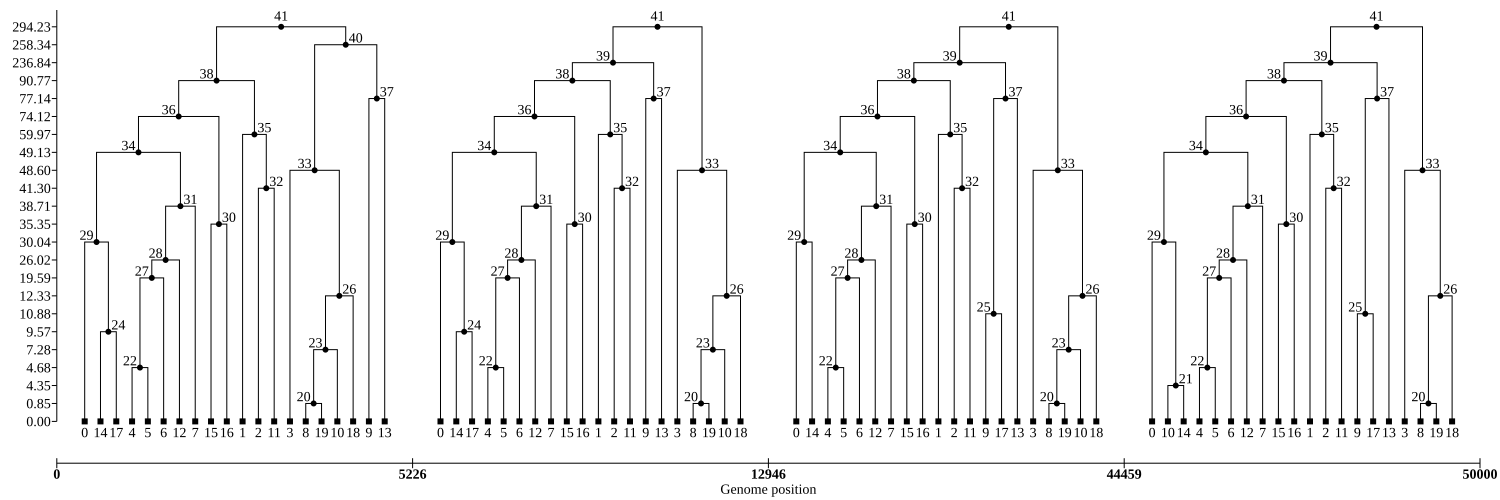

In [4]:
from IPython.display import display
svg_size = (1500, 500)
svg_string = ts_anc.draw_svg(
    size=svg_size,
    y_axis=True, y_label=" ",  # optional: show a time scale on the left
    time_scale="rank", x_scale="treewise",  # Force same axis settings as the text view
)
display(svg_string)

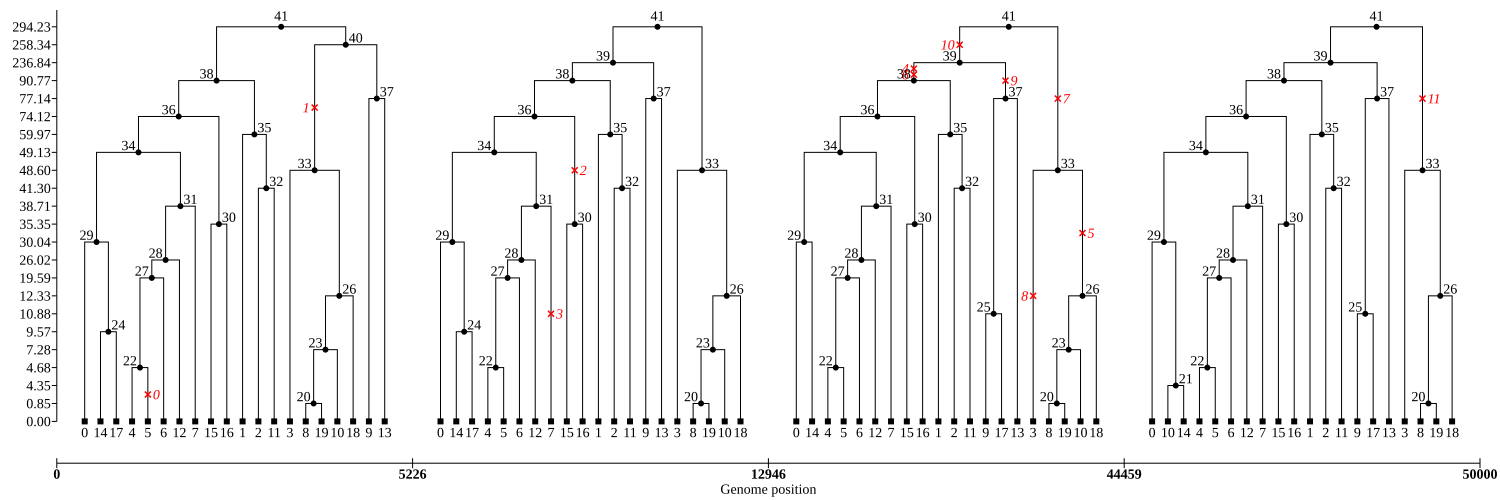

In [5]:
svg_size = (1500, 500)
svg_string = ts.draw_svg(
    size=svg_size,
    y_axis=True, y_label=" ",  # optional: show a time scale on the left
    time_scale="rank", x_scale="treewise",  # Force same axis settings as the text view
)
display(svg_string)

The simulation generates a tree sequence `ts`, which is essentially a record of how all sampled individuals coalesce back to their common ancestors. 

By placing mutations along the branches of these ancestral trees (according to the specified mutation rate), `msprime` outputs simulated genetic variation—ultimately yielding SNP data or variant matrices that can be used for downstream analyses, such as training neural posterior estimators in our pipeline. 

### Let us check the SNP matrix from the tree sequence.

> A quick reminder: the SNP matrix can be seen as the simulated data x, and the parameters used for simulation are the $\theta$.

In [6]:
genotypes = ts.genotype_matrix()  # Shape: (n_variants, n_samples)
print('Genotype matrix shape:', genotypes.shape)

Genotype matrix shape: (12, 20)


This is **one type of data** we can use as the input for our parameter inference later. 

To feed a neural posterior estimator, we need lower-dimensional features. These can be predefined **summary statistics** based on the SNP matrix or features extracted by a neural embedding network (pretrained or learned jointly). 

In this workshop, we will stick with using predefined **summary statistics**.


## Summary statistics: site-frequency spectrum (SFS)
SFS counts how many mutations appear in exactly k haploids. We can use the `tskit` package to extract the SFS directly.

> Folded SFS counts derived and ancestral alleles together, ignoring which allele is ancestral. It's useful when you can’t reliably polarize alleles. In this case, bins run from 1 to n/2 minor allele counts.

> Unfolded SFS distinguishes ancestral and derived alleles, so counts go from derived allele count 1 up to n−1. It requires a reliable polarization to know which allele is ancestral.

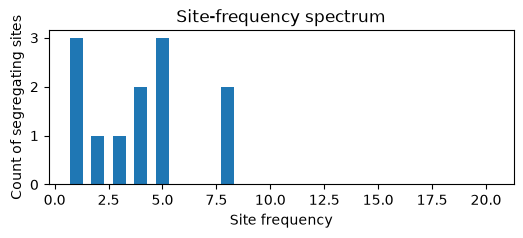

In [7]:
# Compute and plot the folded SFS
sfs = ts.allele_frequency_spectrum(polarised=False, span_normalise=False) # set polarised=True for unfolded SFS
freqs = np.arange(1, len(sfs))

plt.figure(figsize=(6, 2))
plt.bar(freqs, sfs[1:], width=0.6)
plt.xlabel('Site frequency')
plt.ylabel('Count of segregating sites')
plt.title('Site-frequency spectrum')
plt.show()


With SFS, we now have a pair of theta and x (the population parameters, and SFS from its SNP matrix) for NPE.

> SFS reflects the evolutionary history of the population. Larger populations (higher `Ne`) tend to have deeper coalescent trees with more rare variants, while smaller populations coalesce quickly and show fewer segregating sites. 

**What to expect in the comparison below:** larger `Ne` should give more segregating sites in every frequency class, with the excess most visible among rare variants (left side of the spectrum). If you set `recombination_rate = 0`, the spectrum becomes noticeably noisier. Fewer independent genealogies are averaged along the sequence.

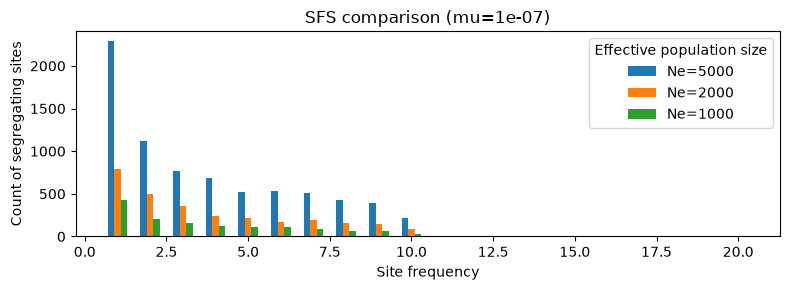

In [8]:
sequence_length = 1000000  # bp
recombination_rate = 1e-7
# recombination_rate = 0 # uncomment to see no recombination effect

ne_values = [5000, 2000, 1000]  # try other values to see how the spectrum shifts

plt.figure(figsize=(8, 3))
for idx, ne_val in enumerate(ne_values):
    demography = msprime.Demography()
    demography.add_population(initial_size=ne_val)

    ts_anc = msprime.sim_ancestry(samples=samples,
                                recombination_rate=recombination_rate,
                                sequence_length=sequence_length,
                                demography=demography)

    ts = msprime.sim_mutations(ts_anc, rate=mutation_rate)
    sfs = ts.allele_frequency_spectrum(span_normalise=False)  # raw counts per frequency class (not normalised)
    freqs = np.arange(1, len(sfs))

    bar_width = 0.6 / len(ne_values)
    offset = (idx - (len(ne_values)-1)/2) * bar_width
    plt.bar(freqs + offset, sfs[1:], width=bar_width, label=f'Ne={ne_val}')

plt.xlabel('Site frequency')
plt.ylabel('Count of segregating sites')
plt.title(f'SFS comparison (mu={mutation_rate})')
plt.legend(title='Effective population size')
plt.tight_layout()
plt.show()


SFS is tightly linked to population parameters: 
- Larger `Ne` lengthens the branches along the tree, reduces the impact of the genetic drift, therefore more mutations can be maintained.
- Higher mutation rates (`μ`) raise the total count of mutations/segregating sites as well. 
- Recombination rate (`r`) reshapes genealogies by creating more independent segments, which flattens linkage and can smooth the spectrum. 

In practice, we use the SFS (our summary statistic `x`) together with the simulator parameters `θ = (Ne, μ, r, ...)` to train a neural posterior estimator. Once trained, the NPE maps an observed SFS to a posterior over the hidden parameters, letting us infer the demography from real genetic data.